# **📌 Bank Marketing ML**

# **Import Modules**

In [40]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTENC

import matplotlib.pyplot as plt 
import seaborn as sns

# **Load Dataset**

In [2]:
train = pd.read_csv('train.csv')

test = pd.read_csv('test.csv')

# **Data Understanding**

In [3]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [4]:
train.shape

(750000, 18)

In [5]:
test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [6]:
test.shape

(250000, 17)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [8]:
train['y'].value_counts()

y
0    659512
1     90488
Name: count, dtype: int64

In [9]:
test_ids = test['id']

# **Feature Selection**

In [10]:
drop_cols = ['y','job','marital','education','contact','housing','loan','day','month','poutcome','id']

In [11]:
X = train.drop(columns=drop_cols)

y_raw = train['y']


## **Encode target**

In [12]:
le = LabelEncoder()

In [13]:
y = le.fit_transform(y_raw)

In [14]:
X_test_final = test.drop(columns=drop_cols, errors='ignore')

In [15]:
print("Train features:", X.columns.tolist())
print("Test features :", X_test_final.columns.tolist())

Train features: ['age', 'default', 'balance', 'duration', 'campaign', 'pdays', 'previous']
Test features : ['age', 'default', 'balance', 'duration', 'campaign', 'pdays', 'previous']


In [16]:
train['default'].unique()

array(['no', 'yes'], dtype=object)

# **Feature Types**

In [17]:
num_cols = ['age','balance','duration','campaign','pdays','previous']

cat_cols = ['default']

# **Preprocessing Pipelines**


In [18]:
num_pipe = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[["no","yes"]], handle_unknown='use_encoded_value', unknown_value=-1))
])

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

# **Train-Test Split**

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
X_train.shape

(600000, 7)

In [22]:
y_train.shape

(600000,)

In [23]:
X.shape

(750000, 7)

In [24]:
y.shape

(750000,)

# **Initial Logistic Regression without SMOTE**

In [25]:
lgr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [26]:
lgr_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
lgr_pipe.score(X_valid, y_valid)

0.8945733333333333

In [28]:
from sklearn.metrics import accuracy_score

y_pred = lgr_pipe.predict(X_valid)

accuracy_score(y_valid, y_pred)


0.8945733333333333

In [29]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94    131902
           1       0.63      0.31      0.41     18098

    accuracy                           0.89    150000
   macro avg       0.77      0.64      0.68    150000
weighted avg       0.88      0.89      0.88    150000



In [30]:
print(confusion_matrix(y_valid, y_pred))

[[128590   3312]
 [ 12502   5596]]



# **Check Imbalance**

In [31]:
df = pd.DataFrame(y_raw.value_counts())

In [32]:
df

,count
y,
0,659512
1,90488


**Data is Imblanced So we have to perform Smote operation**

# **SMOTE for Imbalanced Data**

In [33]:
cat_feature_idx = [X.columns.get_loc(c) for c in cat_cols]

smotenc = SMOTENC(categorical_features=cat_feature_idx, random_state=42)
X_train_res, y_train_res = smotenc.fit_resample(X_train, y_train)


# **Model Building & Evaluation**

# **Using Logistic Regression**

In [34]:
lgr_pipe.fit(X_train_res, y_train_res)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
lgr_pipe.score(X_valid, y_valid)

0.8257133333333333

In [36]:
from sklearn.metrics import accuracy_score

y_pred_res = lgr_pipe.predict(X_valid)

accuracy_score(y_valid, y_pred_res)

0.8257133333333333

In [37]:
print(classification_report(y_valid, y_pred_res))

              precision    recall  f1-score   support

           0       0.97      0.83      0.89    131902
           1       0.39      0.78      0.52     18098

    accuracy                           0.83    150000
   macro avg       0.68      0.81      0.71    150000
weighted avg       0.90      0.83      0.85    150000



In [38]:
print(confusion_matrix(y_valid, y_pred_res))

[[109685  22217]
 [  3926  14172]]



Best Threshold (Youden's J): 0.3181
Validation ROC-AUC: 0.8920


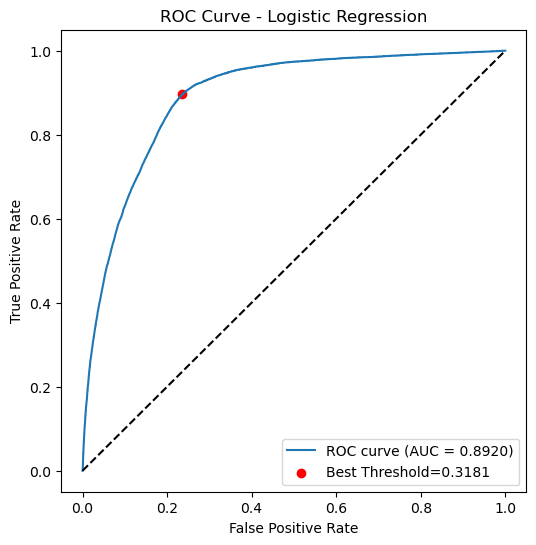

In [41]:
# =============================
# 📌 ROC-AUC & Optimal Threshold
# =============================
y_proba = lgr_pipe.predict_proba(X_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, y_proba)
roc_auc = auc(fpr, tpr)

# Youden's J statistic (sensitivity + specificity - 1)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest Threshold (Youden's J): {best_thresh:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.scatter(fpr[best_idx], tpr[best_idx],
            color='red', label=f"Best Threshold={best_thresh:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [39]:
from collections import Counter

print("Before:", Counter(y_train))
print("After:", Counter(y_train_res))


Before: Counter({0: 527610, 1: 72390})
After: Counter({0: 527610, 1: 527610})


In [43]:
X_train_res

,age,default,balance,duration,campaign,pdays,previous
0,53,no,5,53,1,-1,0
1,40,no,759,68,1,-1,0
2,53,no,1473,509,2,-1,0
3,24,no,855,1205,1,-1,0
4,49,no,2058,1842,1,-1,0
...,...,...,...,...,...,...,...
1055215,66,no,2542,210,1,-1,0
1055216,42,no,894,296,3,-1,0
1055217,32,no,3636,817,1,-1,0
1055218,24,no,1633,194,2,101,1


# **Decision Tree**

In [88]:
dt_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [89]:
dt_pipe.fit(X_train_res, y_train_res)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['no',
                                                                                               'yes']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['default'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [90]:
dt_pipe.score(X_valid, y_valid)

0.8616333333333334

In [92]:
y_pred_dt = dt_pipe.predict(X_valid)

accuracy_score(y_valid, y_pred_dt)

0.8616333333333334

In [93]:
print(classification_report(y_valid, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92    131795
           1       0.45      0.69      0.55     18205

    accuracy                           0.86    150000
   macro avg       0.70      0.79      0.73    150000
weighted avg       0.89      0.86      0.87    150000



# **Random Forest**

In [100]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, n_jobs=-1))
])

In [101]:
rf_pipe.fit(X_train_res, y_train_res)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['no',
                                                                                               'yes']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['default'])])),
                ('model', RandomForestClassifier(n_jobs=-1))])

In [102]:
y_pred_rf = rf_pipe.predict(X_valid)

accuracy_score(y_valid, y_pred_rf)

0.87062

In [103]:
print(classification_report(y_valid, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92    131795
           1       0.48      0.81      0.60     18205

    accuracy                           0.87    150000
   macro avg       0.73      0.84      0.76    150000
weighted avg       0.91      0.87      0.88    150000



# **Evaluation with Cross Validation**

**Using Prediction**

In [44]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
    #"Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)
}

# ==============================
# Evaluation Loop + Cross Validation (Accuracy)
# ==============================
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    pipe.fit(X_train_res, y_train_res)

    val_preds = pipe.predict(X_valid)

    # Cross validation (on full original X, y)
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy", n_jobs=-1)

    print(f"\n=== {name} ===")
    print(classification_report(y_valid, val_preds))
    print("Validation Accuracy:", accuracy_score(y_valid, val_preds))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, val_preds))
    print("CrossVal Accuracy: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.83      0.89    131902
           1       0.39      0.78      0.52     18098

    accuracy                           0.83    150000
   macro avg       0.68      0.81      0.71    150000
weighted avg       0.90      0.83      0.85    150000

Validation Accuracy: 0.8257133333333333
Confusion Matrix:
 [[109685  22217]
 [  3926  14172]]
CrossVal Accuracy: 0.8947 ± 0.0005

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.95      0.89      0.92    131902
           1       0.46      0.69      0.55     18098

    accuracy                           0.86    150000
   macro avg       0.70      0.79      0.73    150000
weighted avg       0.89      0.86      0.87    150000

Validation Accuracy: 0.8633866666666666
Confusion Matrix:
 [[117069  14833]
 [  5659  12439]]
CrossVal Accuracy: 0.8892 ± 0.0010

=== Random Forest ===
             

**Using ROC-AUC Prediction**


=== Logistic Regression ===
ROC-AUC: 0.892
Best Threshold (ROC-J): 0.318

Classification Report (Optimal ROC Threshold):
              precision    recall  f1-score   support

           0       0.98      0.76      0.86    131902
           1       0.34      0.90      0.50     18098

    accuracy                           0.78    150000
   macro avg       0.66      0.83      0.68    150000
weighted avg       0.90      0.78      0.82    150000

Confusion Matrix:
 [[100766  31136]
 [  1874  16224]]

=== Decision Tree ===
ROC-AUC: 0.788
Best Threshold (ROC-J): 0.714

Classification Report (Optimal ROC Threshold):
              precision    recall  f1-score   support

           0       0.95      0.89      0.92    131902
           1       0.46      0.69      0.55     18098

    accuracy                           0.86    150000
   macro avg       0.71      0.79      0.73    150000
weighted avg       0.89      0.86      0.88    150000

Confusion Matrix:
 [[117174  14728]
 [  5667  12431]]


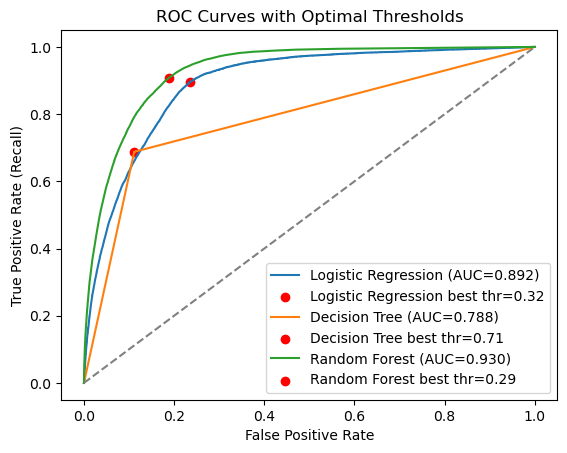

In [50]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1)
}

# ==============================
# Optimal Threshold from ROC Curve
# ==============================
from sklearn.metrics import roc_curve, roc_auc_score

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    pipe.fit(X_train_res, y_train_res)


    # Get probabilities
    y_proba = pipe.predict_proba(X_valid)[:, 1]
   

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_valid, y_proba)
    auc = roc_auc_score(y_valid, y_proba)

    # Find best threshold using Youden’s J statistic
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]

    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {auc:.3f}")
    print(f"Best Threshold (ROC-J): {best_thresh:.3f}")

    # Apply optimal threshold
    y_pred_opt = (y_proba >= best_thresh).astype(int)

    print("\nClassification Report (Optimal ROC Threshold):")
    print(classification_report(y_valid, y_pred_opt))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_opt))

    # ==========================
    # Cross Validation Accuracy
    # ==========================
    #cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    #print("CrossVal Accuracy (no threshold tuning): %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

    # Plot ROC curve with best threshold point
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.scatter(fpr[ix], tpr[ix], marker='o', color='red', 
                label=f"{name} best thr={best_thresh:.2f}")

# Finalize ROC plot
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves with Optimal Thresholds")
plt.legend()
plt.show()


# **Final Model Training & Prediction**

In [43]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(random_state=42))
])
final_pipe.fit(X, y)


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# ==============================
# Final Model Training (Random Forest as example)
# ==============================
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1))
])

final_pipe.fit(X, y)



,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100, n_jobs=-1
    ))
])

final_pipe.fit(X, y)


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# **Predict on Test Data**

**Using Predict on Final Prediction**

In [49]:
# ==============================
# Prediction on Test
# ==============================
final_preds = final_pipe.predict(X_test_final)

**Using Probability Prediction ROC-AUC on Final Prediction**

In [52]:
# Get probabilities for test set
y_test_proba = final_pipe.predict_proba(X_test_final)[:, 1]

# Apply your chosen threshold (say the best one from validation)
final_preds = (y_test_proba >= best_thresh).astype(int)

# **Final Submission**

In [50]:
submission = pd.DataFrame({
    "id": test_ids,   # assumes test.csv has 'id'
    "y": le.inverse_transform(final_preds)  # back to 'yes'/'no'
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved!")

✅ submission1.csv saved!


In [53]:
# Convert to original labels
submission = pd.DataFrame({
    "id": test_ids,
    "y": le.inverse_transform(final_preds)
})
submission.to_csv("submission1.csv", index=False)